<a href="https://colab.research.google.com/github/senchiao/HRRR_plots/blob/main/gradient_calc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install metpy
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units

In [7]:
###########################################
# Create some test data to use for our example
data = np.array([[23, 24, 23],
                 [25, 26, 25],
                 [27, 28, 27],
                 [24, 25, 24]]) * units.degC

# Create an array of x position data (the coordinates of our temperature data)
x = np.array([[1, 2, 3],
              [1, 2, 3],
              [1, 2, 3],
              [1, 2, 3]]) * units.kilometer

y = np.array([[1, 1, 1],
              [2, 2, 2],
              [3, 3, 3],
              [4, 4, 4]]) * units.kilometer

###########################################
# Calculate the gradient using the coordinates of the data
grad = mpcalc.gradient(data, coordinates=(y, x))
print('Gradient in y direction: ', grad[0])
print('Gradient in x direction: ', grad[1])

###########################################
# It's also possible that we do not have the position of data points, but know
# that they are evenly spaced. We can then specify a scalar delta value for each
# axes.
x_delta = 2 * units.km
y_delta = 1 * units.km
grad = mpcalc.gradient(data, deltas=(y_delta, x_delta))
print('Gradient in y direction: ', grad[0])
print('Gradient in x direction: ', grad[1])

###########################################
# Finally, the deltas can be arrays for unevenly spaced data.
x_deltas = np.array([[2, 3],
                     [1, 3],
                     [2, 3],
                     [1, 2]]) * units.kilometer
y_deltas = np.array([[2, 3, 1],
                     [1, 3, 2],
                     [2, 3, 1]]) * units.kilometer
grad = mpcalc.gradient(data, deltas=(y_deltas, x_deltas))
print('Gradient in y direction: ', grad[0])
print('Gradient in x direction: ', grad[1])

Gradient in y direction:  [[2.0 2.0 2.0] [2.0 2.0 2.0] [-0.5 -0.5 -0.5] [-5.5 -5.5 -5.5]] kelvin / kilometer
Gradient in x direction:  [[2.0 0.0 -2.0] [2.0 0.0 -2.0] [2.0 0.0 -2.0] [2.0 0.0 -2.0]] kelvin / kilometer
Gradient in y direction:  [[2.0 2.0 2.0] [2.0 2.0 2.0] [-0.5 -0.5 -0.5] [-5.5 -5.5 -5.5]] kelvin / kilometer
Gradient in x direction:  [[1.0 0.0 -1.0] [1.0 0.0 -1.0] [1.0 0.0 -1.0] [1.0 0.0 -1.0]] kelvin / kilometer
Gradient in y direction:  [[0.3333333333333428 0.6666666666666572 2.333333333333357] [1.6666666666666572 0.6666666666666714 1.6666666666666714] [0.8333333333333286 -0.1666666666666643 -1.6666666666666856] [-3.8333333333333144 -1.8333333333333428 -4.333333333333371]] kelvin / kilometer
Gradient in x direction:  [[0.833333333333357 0.1666666666666714 -0.8333333333333712] [1.333333333333286 0.6666666666666572 -1.3333333333333144] [0.833333333333357 0.1666666666666714 -0.8333333333333428] [1.5000000000000426 0.5000000000000142 -1.5]] kelvin / kilometer


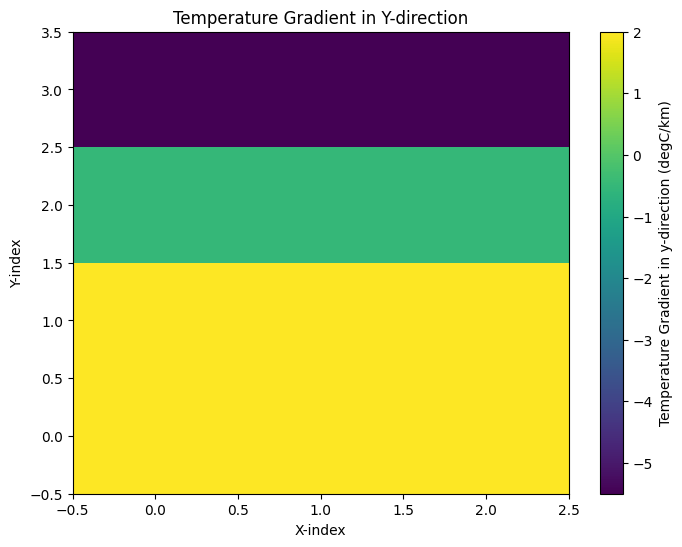

In [10]:


# Plotting the y-direction gradient (grad[0])
plt.figure(figsize=(8, 6))
plt.imshow(grad[0].to('delta_degC/km').magnitude, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Temperature Gradient in y-direction (degC/km)')
plt.title('Temperature Gradient in Y-direction')
plt.xlabel('X-index')
plt.ylabel('Y-index')
plt.show()



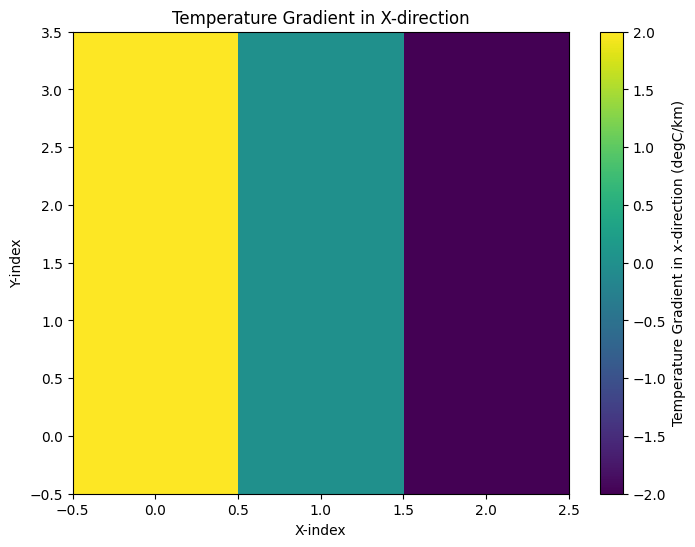

In [11]:
# To plot the x-direction gradient, you would use grad[1] instead:
plt.figure(figsize=(8, 6))
plt.imshow(grad[1].to('delta_degC/km').magnitude, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Temperature Gradient in x-direction (degC/km)')
plt.title('Temperature Gradient in X-direction')
plt.xlabel('X-index')
plt.ylabel('Y-index')
plt.show()